In [1]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [2]:
# Liste des couples (condition, dataset) à analyser
dataset = "form_50_35_15_cgc_0_20"
experiments = [(f"3mod_basic_s{x}", dataset) for x in range(1, 40)]

checkpoint_epoch = 0
n_samples_test = 500
split = "test"

all_metrics = {}  # clé : "condition / dataset"

for condition, dataset in experiments:
    with total_silence():
        experiment_name = get_experiment_name(condition, dataset, 0)
        global_workspace, domain_mods, gw_mod, visual_module, \
            original_data, latent_domains, modules_name = \
            get_modules_data_from_exp(
                experiment_name=experiment_name,
                n_samples_test=n_samples_test,
                split=split,
                checkpoint_epoch=checkpoint_epoch,
            )

    objects = get_objects_from_v_latents(
        latent_domains, gw_mod, global_workspace, modules_name,
        modality_from='attr', modality_through='color',
        modality_main=['attr'], modality_add='color', start_v=True,
    )

    cat = []
    if 'attr' in modules_name:
        cat = original_data['attr'][0]
    if 'cat' in modules_name:
        cat = original_data['cat']

    colors_np = objects['x2']['color'].detach().cpu().numpy()
    cats = cat.argmax(dim=1).detach().cpu().numpy()

    metrics, _ = hue_analysis(
        colors_np, cats, cat_names=CAT_NAMES, value=0.75, saturation_boost=1.8
    )
    label = f"{condition} / {dataset}"
    all_metrics[label] = metrics['per_cat']

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning

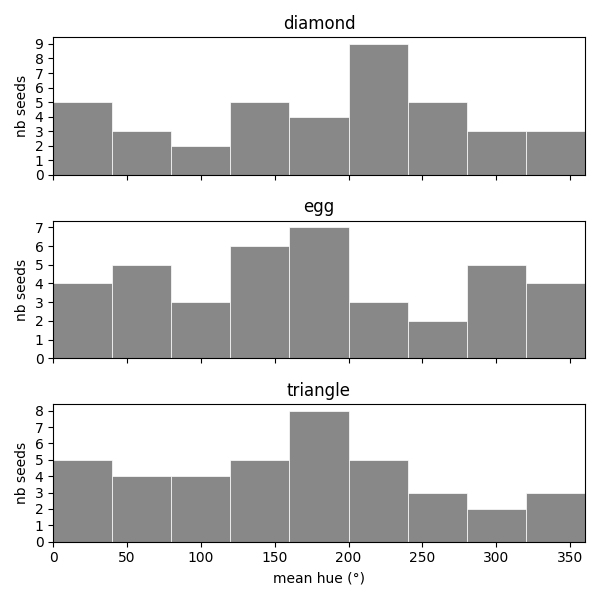

In [5]:
import matplotlib.pyplot as plt
import numpy as np

BIN_SIZE = 40
bins = np.arange(0, 361, BIN_SIZE)
n_cats = len(CAT_NAMES)
fig, axes = plt.subplots(n_cats, 1, figsize=(6, 2 * n_cats), sharex=True)

for ci, ax in enumerate(axes):
    hues = [all_metrics[label][ci]['mean_hue'] for label in all_metrics]
    ax.hist(hues, bins=bins, color='#888888', edgecolor='white', linewidth=0.5)
    ax.set_ylabel("nb seeds")
    ax.set_title(CAT_NAMES[ci], fontsize=12)
    ax.set_xlim(0, 360)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

axes[-1].set_xlabel("mean hue (°)")
fig.tight_layout()
plt.show()